# PCB Binary Classifier - Custom CNN
Custom CNN using LinearBottleneckBlocks for PCB / not-PCB detection.
Targets OpenMV H7 deployment via INT8 TFLite.

## 1. Imports

In [14]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow import data as tf_data
from tensorflow import lite

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)

TF version: 2.19.0
Keras version: 3.10.0


## 2. Config

In [15]:
INPUT_SIZE = 96       # must match model input_shape
BATCH_SIZE = 32
EPOCHS     = 30      # early stopping will cut this short if needed
CLASS_NUM  = 2
LABELS     = ["not_pcb", "pcb"]   # alphabetical — matches Keras inferred order

TRAIN_DIR    = "/kaggle/working/balanced/train"
VALIDATE_DIR = "/kaggle/working/balanced/validate"
TEST_DIR     = "/kaggle/working/balanced/test"

## 3. Rebalance Dataset

In [16]:
val_not_pcb = "/kaggle/input/datasets/hassenalrubei/pcbvnotpcb/dataset/validate/not_pcb"
files = os.listdir(val_not_pcb)
random.seed(42)
keep = set(random.sample(files, 51))  # match PCB count

for split in ["train", "validate", "test"]:
    for cls in ["pcb", "not_pcb"]:
        src = f"/kaggle/input/datasets/hassenalrubei/pcbvnotpcb/dataset/{split}/{cls}"
        dst = f"/kaggle/working/balanced/{split}/{cls}"
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            if split == "validate" and cls == "not_pcb" and f not in keep:
                continue
            shutil.copy(os.path.join(src, f), dst)

for split in ["train", "validate", "test"]:
    path = f"/kaggle/working/balanced/{split}"
    counts = {c: len(os.listdir(os.path.join(path, c))) for c in os.listdir(path)}
    print(f"{split}: {counts}")

train: {'pcb': 847, 'not_pcb': 1116}
validate: {'pcb': 51, 'not_pcb': 51}
test: {'pcb': 102, 'not_pcb': 240}


## 4. Data Augmentation & Loading

Normalisation uses `img / 127.5 - 1` to map pixels to `[-1, 1]`.

In [17]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

def load_ds(path, augment=False, shuffle=False):
    ds = keras.utils.image_dataset_from_directory(
        path,
        validation_split=None,
        seed=1337,
        shuffle=shuffle,
        image_size=(INPUT_SIZE, INPUT_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="categorical",   # one-hot labels → use CategoricalCrossentropy
        class_names=LABELS,
    )
    if augment:
        ds = ds.map(
            lambda img, label: (data_augmentation(img) / 127.5 - 1, label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda img, label: (img / 127.5 - 1, label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    return ds.prefetch(tf_data.AUTOTUNE)

train_ds    = load_ds(TRAIN_DIR,    augment=True,  shuffle=True)
validate_ds = load_ds(VALIDATE_DIR, augment=False, shuffle=False)
test_ds     = load_ds(TEST_DIR,     augment=False, shuffle=False)

print("Classes:", LABELS)

Found 1963 files belonging to 2 classes.
Found 102 files belonging to 2 classes.
Found 342 files belonging to 2 classes.
Classes: ['not_pcb', 'pcb']


## 5. Build Model

LinearBottleneckBlock from EtinyNet. Input shape matches `INPUT_SIZE` from config.

In [18]:
class LinearBottleneckBlock(keras.layers.Layer):
  """Custom Linear Bottleneck Layer from EtinyNet."""
  def __init__(self, out_channels: int, kernel_size: int, padding: str = 'same', strides: int = 1, bias: bool = True) -> None:
    super().__init__()
    self.depthwise_conv_layer_a = keras.layers.DepthwiseConv2D(kernel_size=kernel_size, padding=padding, strides=strides, use_bias=bias)
    self.depthwise_a_batch_norm_layer = keras.layers.BatchNormalization()

    self.pointwise_layer = keras.layers.Conv2D(out_channels, kernel_size=1, padding='same', strides=1, use_bias=bias)
    self.pointwise_batch_norm = keras.layers.BatchNormalization()

    self.depthwise_conv_layer_b = keras.layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same", strides=1, use_bias=bias)
    self.depthwise_b_batch_norm_layer = keras.layers.BatchNormalization()

    self.activation = keras.layers.Activation('relu')

  def call(self, input_tensor: tf.Tensor, training: bool = True) -> tf.Tensor:
    """Forward Pass for the Linear Bottleneck Layer."""
    depthwise_result = self.depthwise_a_batch_norm_layer(self.depthwise_conv_layer_a(input_tensor), training=training)
    pointwise_result = self.activation(self.pointwise_batch_norm(self.pointwise_layer(depthwise_result), training=training))
    output = self.activation(self.depthwise_b_batch_norm_layer(self.depthwise_conv_layer_b(pointwise_result), training=training))
    return output

In [19]:
model = keras.Sequential([
  # FIX: input_shape now uses INPUT_SIZE from config (was hardcoded to 32x32)
  keras.layers.Conv2D(filters=16, kernel_size=5, padding='same', strides=1, input_shape=(INPUT_SIZE, INPUT_SIZE, 3)),
  keras.layers.BatchNormalization(),
  keras.layers.Activation("relu"),
  keras.layers.MaxPooling2D(pool_size=2),
  LinearBottleneckBlock(out_channels=32, kernel_size=3),
  LinearBottleneckBlock(out_channels=64, kernel_size=3),
  keras.layers.MaxPooling2D(pool_size=2),
  LinearBottleneckBlock(out_channels=64, kernel_size=3),
  LinearBottleneckBlock(out_channels=128, kernel_size=3),
  keras.layers.GlobalAveragePooling2D(),
  keras.layers.Dropout(0.3),
  # FIX: units=CLASS_NUM (was 10 — wrong for a 2-class problem)
  keras.layers.Dense(units=CLASS_NUM, kernel_regularizer=keras.regularizers.L2(1e-3))
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 96, 96, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_bottleneck_block_8       │ (None, 48, 48, 32)     │         1,344 │
│ (LinearBottleneckBlock)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_bottleneck_block_9       │ (None, 48, 48, 64)     │         3,712 │
│ (LinearBottleneckBlock)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_bottleneck_block_10      │ (None, 24, 24, 64)     │         6,208 │
│ (LinearBottleneckBlock)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ linear_bottleneck_block_11      │ (None, 24, 24, 128)    │        11,520 │
│ (LinearBottleneckBlock)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,322 (95.01 KB)

 Trainable params: 22,786 (89.01 KB)

 Non-trainable params: 1,536 (6.00 KB)

## 6. Compile & Train

In [26]:
# FIX: CategoricalCrossentropy matches label_mode="categorical" (was SparseCategoricalCrossentropy)
loss_function = keras.losses.CategoricalCrossentropy(from_logits=True)
LEARNING_RATE = 0.01
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

lr_scheduler  = keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=5, verbose=1, min_lr=0, min_delta=0.001)
early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', verbose=1, patience=8, min_delta=0.001)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    verbose=2,
    validation_data=validate_ds,
    callbacks=[lr_scheduler, early_stopping]
)



Epoch 1/30
62/62 - 34s - 547ms/step - accuracy: 0.8874 - loss: 0.2747 - val_accuracy: 0.8922 - val_loss: 0.3254 - learning_rate: 0.0100
Epoch 2/30
62/62 - 2s - 34ms/step - accuracy: 0.9144 - loss: 0.2197 - val_accuracy: 0.9118 - val_loss: 0.2246 - learning_rate: 0.0100
Epoch 3/30
62/62 - 2s - 33ms/step - accuracy: 0.9088 - loss: 0.2336 - val_accuracy: 0.9314 - val_loss: 0.2373 - learning_rate: 0.0100
Epoch 4/30
62/62 - 2s - 34ms/step - accuracy: 0.9119 - loss: 0.2191 - val_accuracy: 0.9412 - val_loss: 0.3059 - learning_rate: 0.0100
Epoch 5/30
62/62 - 2s - 34ms/step - accuracy: 0.9200 - loss: 0.2031 - val_accuracy: 0.8725 - val_loss: 0.5024 - learning_rate: 0.0100
Epoch 6/30
62/62 - 2s - 34ms/step - accuracy: 0.9185 - loss: 0.1972 - val_accuracy: 0.9216 - val_loss: 0.2101 - learning_rate: 0.0100
Epoch 7/30
62/62 - 2s - 33ms/step - accuracy: 0.9134 - loss: 0.2120 - val_accuracy: 0.7255 - val_loss: 0.8911 - learning_rate: 0.0100
Epoch 8/30
62/62 - 2s - 33ms/step - accuracy: 0.9266 - loss:

## 7. Evaluate on Test Set

In [27]:
loss, acc = model.evaluate(test_ds)
print(f"Test accuracy: {acc:.2%}  |  Test loss: {loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.9235 - loss: 0.2923
Test accuracy: 92.98%  |  Test loss: 0.2584


## 8. Training History

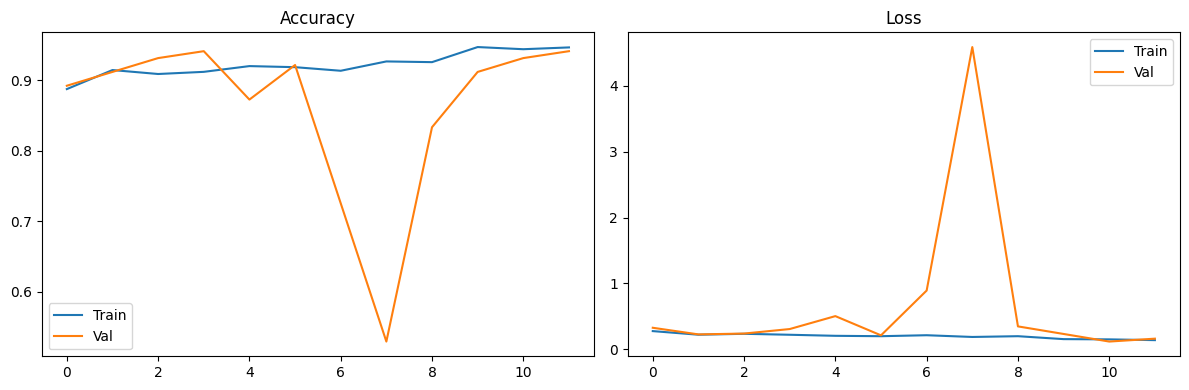

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# FIX: renamed history_top → history (was a leftover from MobileNetV2 notebook)
axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Convert to INT8 TFLite



In [30]:
def representative_dataset():
    for images, _ in train_ds.take(100):
    for img in images:
        yield [tf.expand_dims(img, 0)]

converter = lite.TFLiteConverter.from_keras_model(model)
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
converter.optimizations = [lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("trained.tflite", "wb") as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpe9x6ys_n/assets


INFO:tensorflow:Assets written to: /tmp/tmpe9x6ys_n/assets


Saved artifact at '/tmp/tmpe9x6ys_n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_34')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136310385227920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588365264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588365648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588361232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588361040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588360272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588361424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588365072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588364112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136310588363152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1363105883629

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772289368.743615      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772289368.743649      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772289368.787754      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


TFLite model size: 53.0 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 10. Verify Model Loads 

In [31]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:",  input_details[0]["shape"],  "dtype:", input_details[0]["dtype"])
print("Output:", output_details[0]["shape"], "dtype:", output_details[0]["dtype"])

# Tensor arena estimate
details = interpreter.get_tensor_details()
total = sum(
    abs(np.prod(t["shape"])) * np.dtype(t["dtype"]).itemsize
    for t in details
)
print(f"Estimated tensor arena: {total / 1024:.1f} KB")
print(f"File size: {os.path.getsize('trained.tflite') / 1024:.1f} KB")
print("allocate_tensors() passed — model should load on OpenMV")

Input: [ 1 96 96  3] dtype: <class 'numpy.int8'>
Output: [1 2] dtype: <class 'numpy.int8'>
Estimated tensor arena: 1094.1 KB
File size: 53.0 KB
allocate_tensors() passed — model should load on OpenMV


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 11. Generate labels.txt

Required alongside `trained.tflite` on the OpenMV drive.

In [32]:
with open("labels.txt", "w") as f:
    f.write("\n".join(LABELS))

print("labels.txt contents:")
print(open("labels.txt").read())

labels.txt contents:
not_pcb
pcb


## 12. Download Files

Copy `trained.tflite` and `labels.txt` to your OpenMV drive.

In [ ]:
print("Files ready to download:")
for fname in ["trained.tflite", "labels.txt"]:
    size = os.path.getsize(fname)
    print(f"  {fname}: {size / 1024:.1f} KB")

